# 数据集加载及预处理

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [2]:
for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [3]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [4]:
class WideDeep(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 30), #30个神经元
            nn.ReLU(),
            nn.Linear(30, 30), #30个神经元
            nn.ReLU()
            )
        # pytorch 需要自行计算输出输出维度
        self.output_layer = nn.Linear(30 + input_dim, 1)
        
        # 初始化权重
        self.init_weights()
        
    def init_weights(self):
        """使用 xavier 均匀分布来初始化全连接层的权重 W"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # x.shape [batch size, 8]
        deep_output = self.deep(x)
        # print(deep_output.shape) # [batch size, 30]
        # concat [batch size, 30] with x [batch size 8]，得到 [batch size, 38]
        concat = torch.cat([x, deep_output], dim=1)
        logits = self.output_layer(concat) # 输出层，输入维度是 38，输出维度是 1
        # logits.shape [batch size, 1]
        return logits


In [5]:
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 前向计算验证 WideDeep 模型
# 创建模型实例并移动到合适设备
model = WideDeep(input_dim=8)
model.to(device)  # 可根据实际设备选择 'cuda' 或 'cpu'

# 随机生成一个与输入维度匹配的批量样本
x_sample = torch.randn(4, 8)  # 假设batch size为4, 特征数为8
output = model(x_sample)

print(f"输入形状: {x_sample.shape}")
print(f"模型输出形状: {output.shape}")
print(f"模型输出内容:\n{output}")


使用设备: cpu
输入形状: torch.Size([4, 8])
模型输出形状: torch.Size([4, 1])
模型输出内容:
tensor([[ 0.0066],
        [-0.0265],
        [-0.6560],
        [-0.2202]], grad_fn=<AddmmBackward0>)


In [6]:
# 导入训练模块
from trainmodule_train import Trainer, EarlyStopping, ModelCheckpoint




# 初始化损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数，适用于回归任务
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 初始化早停对象
early_stopping = EarlyStopping(
    patience=10,      # 容忍10个评估周期没有改善
    min_delta=0.001,  # 最小改善阈值
    mode='min'        # 监控val_loss，越小越好
)

# 初始化模型保存对象
model_checkpoint = ModelCheckpoint(
    filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    min_delta=0.001
)

# 创建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=50,  # 每50个batch评估一次
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint
)

# 开始训练
print("开始训练...")
trainer.train_regression(num_epochs=100)


开始训练...
[Step 50] Val Loss: 1.2361
[Step 100] Val Loss: 0.8200
[Step 150] Val Loss: 0.7332
[Step 200] Val Loss: 0.6774
Epoch [1/100]  Train Loss: 1.2527
[Step 250] Val Loss: 0.6267
[Step 300] Val Loss: 0.5799
[Step 350] Val Loss: 0.5443
[Step 400] Val Loss: 0.5112
[Step 450] Val Loss: 0.4922
Epoch [2/100]  Train Loss: 0.5556
[Step 500] Val Loss: 0.4688
[Step 550] Val Loss: 0.4559
[Step 600] Val Loss: 0.4498
[Step 650] Val Loss: 0.4389
Epoch [3/100]  Train Loss: 0.4487
[Step 700] Val Loss: 0.4369
[Step 750] Val Loss: 0.4281
[Step 800] Val Loss: 0.4196
[Step 850] Val Loss: 0.4168
[Step 900] Val Loss: 0.4189
Epoch [4/100]  Train Loss: 0.4135
[Step 950] Val Loss: 0.4100
[Step 1000] Val Loss: 0.4039
[Step 1050] Val Loss: 0.4029
[Step 1100] Val Loss: 0.4019
Epoch [5/100]  Train Loss: 0.3929
[Step 1150] Val Loss: 0.3985
[Step 1200] Val Loss: 0.3931
[Step 1250] Val Loss: 0.3917
[Step 1300] Val Loss: 0.3882
[Step 1350] Val Loss: 0.3865
Epoch [6/100]  Train Loss: 0.3802
[Step 1400] Val Loss: 0.3

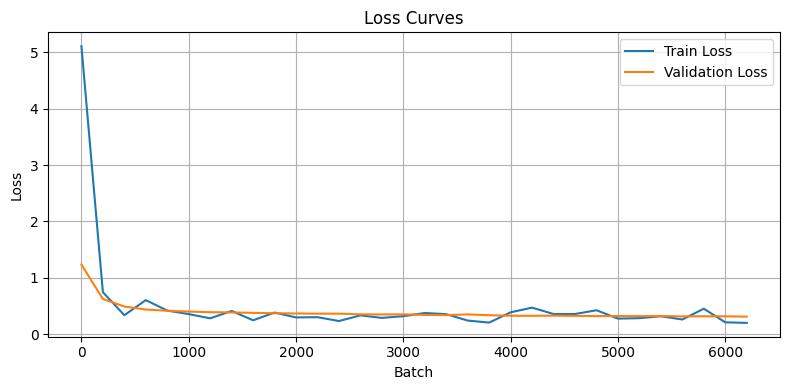

In [7]:
trainer.plot_curves(200)